# 07 — Error Analysis and Model Failure Modes

This notebook diagnoses the final tuned Random Forest without changing the model. It studies prediction errors by band-gap range, uncertainty, crystal system, chemical system, and individual material, then saves reusable results for the project.

In [1]:
import re, json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from jarvis.db.figshare import data
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.models import create_model_pipeline
from src.preprocessing import FEATURE_COLUMNS
RESULTS, FIGURES = ROOT/'results', ROOT/'figures'
RESULTS.mkdir(exist_ok=True); FIGURES.mkdir(exist_ok=True)
print('Project root:', ROOT)


Project root: F:\Quantum-materials


## 1. Load data and reproduce the official test split

The split matches Notebook 03: 80/20, `random_state=42`, stratified by zero/non-zero band gap. JARVIS IDs and formulas are attached for interpretation.

In [2]:
df = pd.read_csv(ROOT/'data'/'enhanced_material_descriptors.csv')
jarvis_df = pd.DataFrame(data('dft_3d'))
assert len(df) == len(jarvis_df), 'Descriptor/JARVIS row mismatch.'
df = df.copy()
df.insert(0, 'jid', jarvis_df['jid'].astype(str).to_numpy())
df.insert(1, 'formula', jarvis_df['formula'].astype(str).to_numpy())

X, y = df[FEATURE_COLUMNS].copy(), pd.to_numeric(df['target_bandgap'], errors='coerce')
assert y.notna().all()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=(y > 0).astype(int))
test_meta = df.loc[X_test.index, ['jid','formula','crys','spg_number']].copy()
print('Train:', X_train.shape, 'Test:', X_test.shape)


Obtaining 3D dataset 94k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
Train: (75121, 25) Test: (18781, 25)


## 2. Refit the final tuned model on the training partition

This uses the exact final configuration from Notebook 03. The resulting test metrics should reproduce MAE ≈ 0.2381 eV, RMSE ≈ 0.5559 eV, R² ≈ 0.8195.

In [3]:
pipeline = create_model_pipeline()
pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)
print(f'MAE  : {mae:.4f} eV')
print(f'RMSE : {rmse:.4f} eV')
print(f'R²   : {r2:.4f}')


MAE  : 0.2381 eV
RMSE : 0.5559 eV
R²   : 0.8195


In [4]:
analysis = test_meta.copy().reset_index(drop=True)
analysis['actual_bandgap'] = y_test.to_numpy()
analysis['predicted_bandgap'] = pred
analysis['residual'] = analysis['actual_bandgap'] - analysis['predicted_bandgap']
analysis['absolute_error'] = analysis['residual'].abs()
analysis.head()


,jid,formula,crys,spg_number,actual_bandgap,predicted_bandgap,residual,absolute_error
0,JVASP-42848,Pr2IrPd,cubic,225,0.000,0.000000,0.000000,0.000000
1,JVASP-38868,Dy2MgGe2,tetragonal,127,0.000,0.000000,0.000000,0.000000
2,JVASP-146915,Mn6O11F,monoclinic,5,0.000,0.009025,-0.009025,0.009025
3,JVASP-189155,TiZnNiRh,cubic,216,0.000,0.000000,0.000000,0.000000
4,JVASP-50354,TaCuO3,monoclinic,12,1.658,0.307879,1.350121,1.350121


## 3. Predicted vs actual

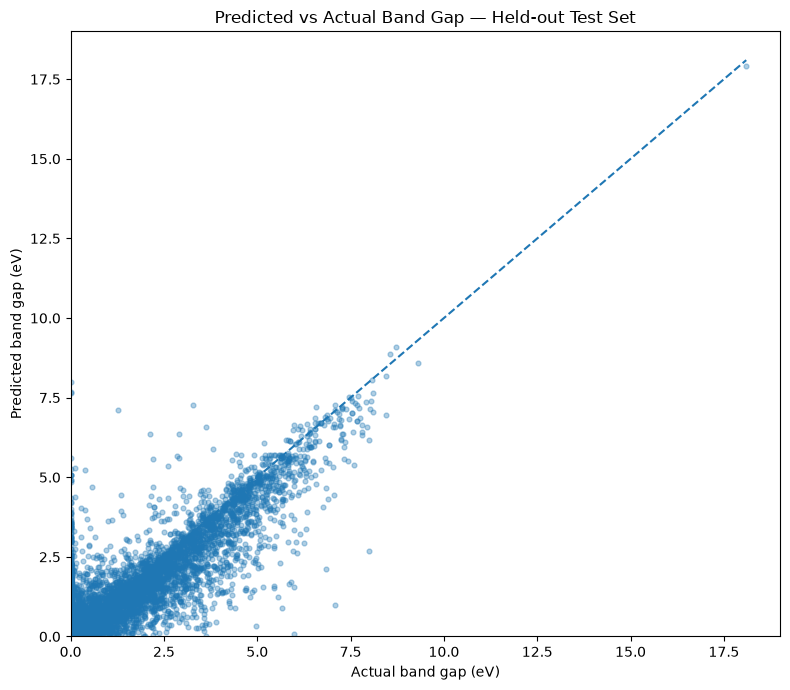

In [5]:
plt.figure(figsize=(8,7))
plt.scatter(analysis.actual_bandgap, analysis.predicted_bandgap, s=12, alpha=0.35)
m = max(analysis.actual_bandgap.max(), analysis.predicted_bandgap.max())
plt.plot([0,m],[0,m],'--')
plt.xlabel('Actual band gap (eV)'); plt.ylabel('Predicted band gap (eV)')
plt.title('Predicted vs Actual Band Gap — Held-out Test Set')
plt.xlim(left=0); plt.ylim(bottom=0); plt.tight_layout()
plt.savefig(FIGURES/'error_predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Residuals vs prediction

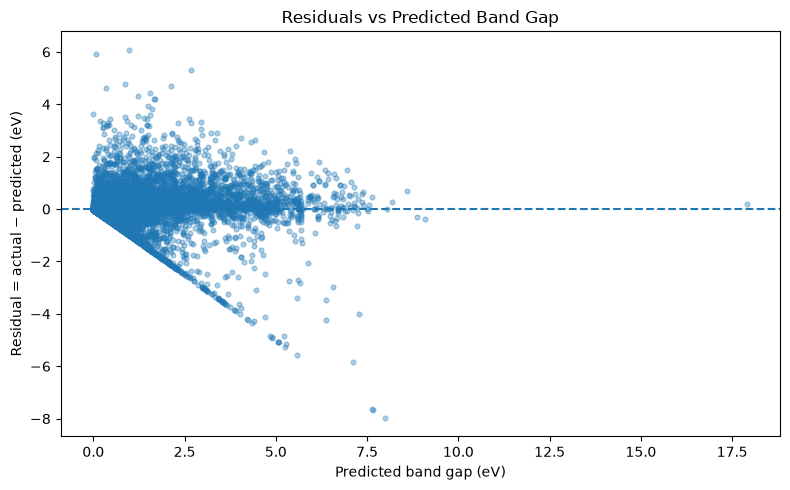

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(analysis.predicted_bandgap, analysis.residual, s=12, alpha=0.35)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted band gap (eV)'); plt.ylabel('Residual = actual − predicted (eV)')
plt.title('Residuals vs Predicted Band Gap'); plt.tight_layout()
plt.savefig(FIGURES/'error_residuals_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Error by actual band-gap range

,bandgap_group,n,MAE_eV,RMSE_eV,mean_actual_eV
0,0 eV,13413,0.114771,0.377395,0.000000
1,1–2 eV,1107,0.465890,0.638997,1.474095
2,0–0.5 eV,1227,0.337314,0.678064,0.216768
3,2–3 eV,850,0.650432,0.880703,2.443320
4,3–5 eV,1031,0.817898,1.136528,3.883061
5,0.5–1 eV,769,0.338817,0.495931,0.734746
6,5–10 eV,383,0.904716,1.348872,6.001128
7,>10 eV,1,0.182557,0.182557,18.098000


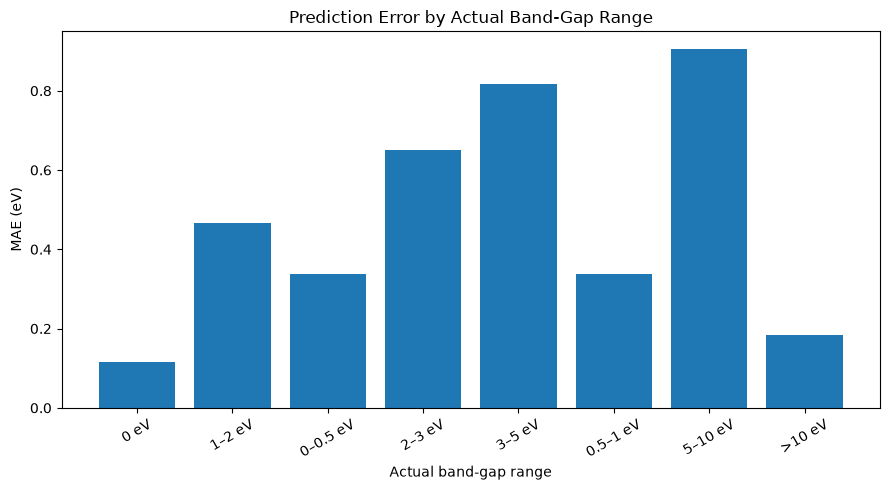

In [7]:
def gap_group(v):
    if v == 0: return '0 eV'
    if v <= .5: return '0–0.5 eV'
    if v <= 1: return '0.5–1 eV'
    if v <= 2: return '1–2 eV'
    if v <= 3: return '2–3 eV'
    if v <= 5: return '3–5 eV'
    if v <= 10: return '5–10 eV'
    return '>10 eV'

analysis['bandgap_group'] = analysis.actual_bandgap.map(gap_group)
error_by_gap = analysis.groupby('bandgap_group', sort=False).agg(
    n=('absolute_error','size'), MAE_eV=('absolute_error','mean'),
    RMSE_eV=('residual', lambda x: np.sqrt(np.mean(x**2))),
    mean_actual_eV=('actual_bandgap','mean')).reset_index()
display(error_by_gap)

plt.figure(figsize=(9,5)); plt.bar(error_by_gap.bandgap_group, error_by_gap.MAE_eV)
plt.xlabel('Actual band-gap range'); plt.ylabel('MAE (eV)')
plt.title('Prediction Error by Actual Band-Gap Range'); plt.xticks(rotation=30)
plt.tight_layout(); plt.savefig(FIGURES/'error_by_bandgap_range.png', dpi=300, bbox_inches='tight'); plt.show()


## 6. Random Forest uncertainty proxy

For every test material we calculate the standard deviation of the 200 individual tree predictions. This is a relative uncertainty proxy, **not** a calibrated prediction interval.

In [8]:
pre = pipeline.named_steps['preprocessor']; forest = pipeline.named_steps['model']
Xt = pre.transform(X_test)
tree_pred = np.vstack([tree.predict(Xt) for tree in forest.estimators_])
tree_mean = tree_pred.mean(axis=0); tree_std = tree_pred.std(axis=0)
print('Max tree-mean/pipeline difference:', np.max(np.abs(tree_mean-pred)))
analysis['prediction_uncertainty'] = tree_std

rho, p = spearmanr(analysis.prediction_uncertainty, analysis.absolute_error)
print(f'Spearman uncertainty/error correlation: {rho:.4f}')
print(f'p-value: {p:.4e}')


Max tree-mean/pipeline difference: 2.6645352591003757e-15
Spearman uncertainty/error correlation: 0.9596
p-value: 0.0000e+00


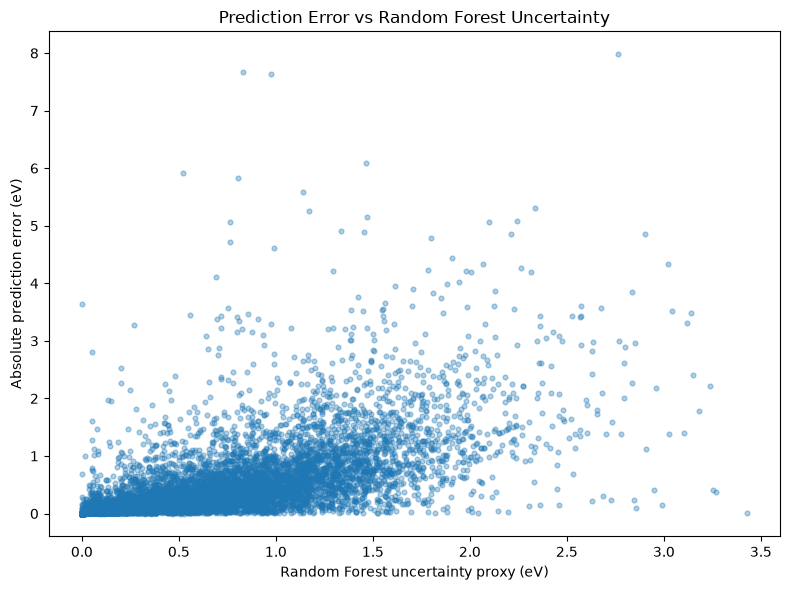

,uncertainty_quartile,n,mean_uncertainty_eV,MAE_eV,RMSE_eV
0,Q1 lowest,4696,0.000000,0.000260,0.011046
1,Q2,4695,0.022369,0.014709,0.096719
2,Q3,4695,0.319009,0.170010,0.304448
3,Q4 highest,4695,1.110804,0.767611,1.064872


In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    analysis["prediction_uncertainty"],
    analysis["absolute_error"],
    s=12,
    alpha=0.35
)

plt.xlabel("Random Forest uncertainty proxy (eV)")
plt.ylabel("Absolute prediction error (eV)")
plt.title("Prediction Error vs Random Forest Uncertainty")
plt.tight_layout()

plt.savefig(
    FIGURES / "error_vs_uncertainty.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# Robust uncertainty grouping
# ---------------------------------------------------------
# Many materials can have identical uncertainty values.
# Ranking first prevents qcut from creating duplicate
# quantile boundaries.

analysis["uncertainty_quartile"] = pd.qcut(
    analysis["prediction_uncertainty"].rank(method="first"),
    q=4,
    labels=[
        "Q1 lowest",
        "Q2",
        "Q3",
        "Q4 highest"
    ]
)


# Calculate error statistics for each uncertainty group
error_by_uncertainty = (
    analysis
    .groupby("uncertainty_quartile", observed=True)
    .agg(
        n=("absolute_error", "size"),
        mean_uncertainty_eV=("prediction_uncertainty", "mean"),
        MAE_eV=("absolute_error", "mean"),
        RMSE_eV=(
            "residual",
            lambda x: np.sqrt(np.mean(x ** 2))
        )
    )
    .reset_index()
)

display(error_by_uncertainty)

## 7. Error by crystal system

,crys,n,MAE_eV,RMSE_eV,mean_uncertainty_eV
5,triclinic,842,0.479565,0.758645,0.664386
2,monoclinic,2413,0.414649,0.744092,0.623588
6,trigonal,1845,0.314517,0.645874,0.465651
3,orthorhombic,2877,0.279171,0.586096,0.424141
4,tetragonal,4130,0.183026,0.483832,0.286794
1,hexagonal,2156,0.153101,0.494202,0.237549
0,cubic,4518,0.132498,0.402419,0.216439


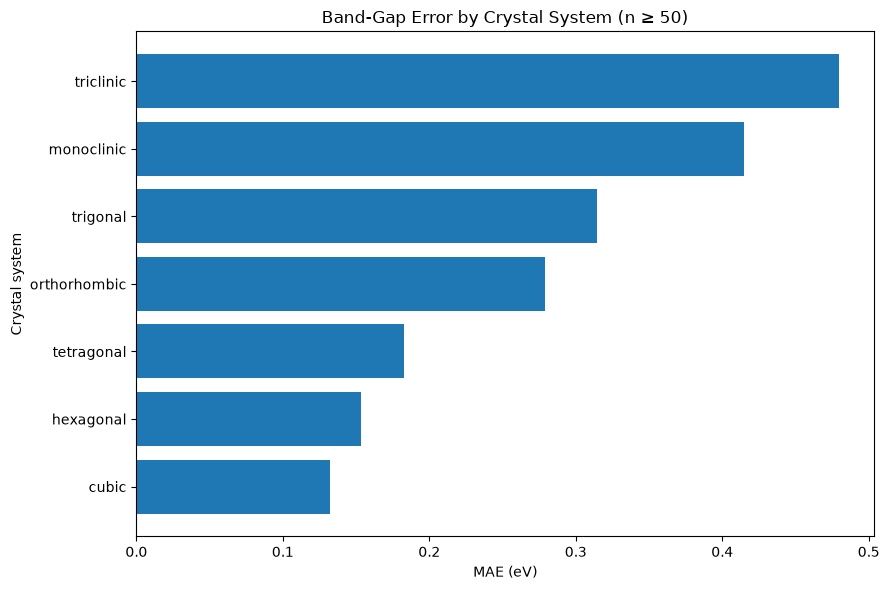

In [11]:
crystal_error = analysis.groupby('crys', dropna=False).agg(
    n=('absolute_error','size'), MAE_eV=('absolute_error','mean'),
    RMSE_eV=('residual', lambda x: np.sqrt(np.mean(x**2))),
    mean_uncertainty_eV=('prediction_uncertainty','mean')).reset_index()
display(crystal_error.sort_values('MAE_eV', ascending=False).head(20))

plot_df = crystal_error[crystal_error.n >= 50].sort_values('MAE_eV')
plt.figure(figsize=(9,6)); plt.barh(plot_df.crys, plot_df.MAE_eV)
plt.xlabel('MAE (eV)'); plt.ylabel('Crystal system'); plt.title('Band-Gap Error by Crystal System (n ≥ 50)')
plt.tight_layout(); plt.savefig(FIGURES/'error_by_crystal_system.png', dpi=300, bbox_inches='tight'); plt.show()


## 8. Chemical-system error analysis

A chemical system is the set of unique elements in a formula, e.g. `LiMnO2 → Li-Mn-O`. This is a chemistry grouping, not a structural identity.

In [12]:
formula_pattern = re.compile(r'([A-Z][a-z]?)')
def chemical_system(formula): return '-'.join(sorted(set(formula_pattern.findall(str(formula)))))
analysis['chemical_system'] = analysis.formula.map(chemical_system)
chemical_error = analysis.groupby('chemical_system').agg(
    n=('absolute_error','size'), MAE_eV=('absolute_error','mean'),
    RMSE_eV=('residual', lambda x: np.sqrt(np.mean(x**2))),
    mean_uncertainty_eV=('prediction_uncertainty','mean')).reset_index()
reliable_chemical = chemical_error[chemical_error.n >= 5].sort_values(['MAE_eV','n'], ascending=[False,False])
print('Test chemical systems:', len(chemical_error))
print('Systems with ≥5 test materials:', len(reliable_chemical))
display(reliable_chemical.head(20))


Test chemical systems: 12098
Systems with ≥5 test materials: 323


,chemical_system,n,MAE_eV,RMSE_eV,mean_uncertainty_eV
8549,H-O,6,1.935233,2.644054,1.403105
7394,F-Mg,6,1.820377,2.387516,1.683044
8500,H-N,5,1.814908,1.964512,1.964093
11242,O-Y,5,1.579418,1.715588,1.527074
4509,C-H,7,1.536885,1.965781,1.668178
8698,Hf-N-O,5,1.503260,1.576712,0.922594
10465,N-O,5,1.473879,1.988343,1.848803
4370,C,12,1.434675,2.031032,0.447545
9429,K-N-O,5,1.292349,1.994446,0.939659
4640,C-N,6,1.243957,1.542692,1.204312


## 9. Worst individual predictions

In [13]:
worst = analysis.sort_values('absolute_error', ascending=False).head(50).reset_index(drop=True)
worst_cols = ['jid','formula','crys','spg_number','chemical_system','actual_bandgap','predicted_bandgap','absolute_error','prediction_uncertainty']
worst = worst[worst_cols]
display(worst)
worst.to_csv(RESULTS/'worst_bandgap_predictions.csv', index=False)


,jid,formula,crys,spg_number,chemical_system,actual_bandgap,predicted_bandgap,absolute_error,prediction_uncertainty
0,JVASP-146789,H,orthorhombic,62,H,0.000,7.978410,7.978410,2.766239
1,JVASP-13976,LiSmAlF6,hexagonal,182,Al-F-Li-Sm,0.000,7.671053,7.671053,0.830780
2,JVASP-96877,K2LiAlF6,hexagonal,191,Al-F-K-Li,0.000,7.632340,7.632340,0.976443
3,JVASP-25226,N,trigonal,167,N,7.072,0.988387,6.083613,1.467128
4,JVASP-22191,Rb2NaTiF6,cubic,225,F-Na-Rb-Ti,5.979,0.070155,5.908845,0.521840
5,JVASP-31179,Na2HF4,monoclinic,10,F-H-Na,1.276,7.103589,5.827589,0.803494
6,JVASP-133348,NaS2O6,monoclinic,14,Na-O-S,0.010,5.592984,5.582984,1.139797
7,JVASP-128497,HeKr,hexagonal,187,He-Kr,7.991,2.688616,5.302384,2.337584
8,JVASP-120477,KLiAl2Si4O10F2,monoclinic,12,Al-F-K-Li-O-Si,0.000,5.256906,5.256906,1.172140
9,JVASP-136394,RbClO4,trigonal,160,Cl-O-Rb,0.125,5.283079,5.158079,1.472174


## 10. Low-uncertainty but high-error cases

These are especially important: if uncertainty is low while error is high, the uncertainty proxy failed to flag a difficult prediction.

In [14]:
analysis['uncertainty_rank'] = analysis.prediction_uncertainty.rank(pct=True)
analysis['error_rank'] = analysis.absolute_error.rank(pct=True)
analysis['uncertainty_error_gap'] = analysis.error_rank - analysis.uncertainty_rank
surprising = analysis.sort_values('uncertainty_error_gap', ascending=False).head(30)[[
    'jid','formula','chemical_system','actual_bandgap','predicted_bandgap','absolute_error','prediction_uncertainty','uncertainty_rank','error_rank'
]].reset_index(drop=True)
display(surprising)
surprising.to_csv(RESULTS/'low_uncertainty_high_error_cases.csv', index=False)


,jid,formula,chemical_system,actual_bandgap,predicted_bandgap,absolute_error,prediction_uncertainty,uncertainty_rank,error_rank
0,JVASP-114576,Ba2NiO,Ba-Ni-O,0.680,0.000000,0.680000,0.000000,0.177733,0.888984
1,JVASP-22712,Li2VF6,F-Li-V,3.636,0.000390,3.635610,0.003160,0.370907,0.997870
2,JVASP-136282,CaPt,Ca-Pt,0.292,0.000000,0.292000,0.000000,0.177733,0.771631
3,JVASP-34584,SiO2,O-Si,2.859,5.672202,2.813202,0.051908,0.453384,0.993717
4,JVASP-121934,LiFeSiO4,Fe-Li-O-Si,0.201,1.195813,0.994813,0.015439,0.400138,0.933017
5,JVASP-185066,Sc2SnRu,Ru-Sc-Sn,0.173,0.000000,0.173000,0.000000,0.177733,0.703690
6,JVASP-112180,CdH10C7O4,C-Cd-H-O,2.258,3.867936,1.609936,0.051578,0.452931,0.973005
7,JVASP-3015,ThCu2P2,Cu-P-Th,0.146,0.000000,0.146000,0.000000,0.177733,0.681700
8,JVASP-34491,SiO2,O-Si,4.431,5.715458,1.284458,0.054167,0.455833,0.956392
9,JVASP-112185,CdH18C11O4,C-Cd-H-O,2.349,3.810243,1.461243,0.079451,0.478595,0.966296


## 11. Save a reusable summary

The output is used for later interpretation and can be connected to the Streamlit Trustworthiness section.

In [15]:
summary = {
  'test_set': {'n_materials': int(len(analysis)), 'mae_eV': float(mae), 'rmse_eV': float(rmse), 'r2': float(r2)},
  'uncertainty': {'method':'Random Forest tree prediction standard deviation', 'calibrated':False, 'spearman_error_correlation':float(rho), 'spearman_p_value':float(p)},
  'error_by_bandgap': error_by_gap.to_dict(orient='records'),
  'error_by_uncertainty': error_by_uncertainty.to_dict(orient='records'),
  'error_by_crystal_system': crystal_error.to_dict(orient='records'),
  'chemical_systems': {'total_test_systems':int(len(chemical_error)), 'systems_with_at_least_5_test_materials':int(len(reliable_chemical))},
  'outputs': ['results/worst_bandgap_predictions.csv','results/low_uncertainty_high_error_cases.csv']
}
with open(RESULTS/'error_analysis_summary.json','w',encoding='utf-8') as f: json.dump(summary,f,indent=4)
print('Saved error-analysis results.')


Saved error-analysis results.


# Interpretation checklist

After running the notebook, answer these questions:

1. Does error increase for larger band gaps?
2. Does Random Forest uncertainty increase when absolute error increases?
3. Which crystal systems have unusually high error?
4. Which chemical systems have unusually high error?
5. Are there low-uncertainty/high-error failures?
6. Do these failures suggest missing structural information?

This notebook is deliberately diagnostic. It does **not** tune the model or change the official test result. Its purpose is to tell us what the next scientific improvement should address.